# WP2: Annotator Style Analysis

•	Compute per-annotator:
   -	lexical diversity
   -	frequent terms
   - report length distributions
   -	structuring 
   
•	Cross-check trends against the analysis already presented in the CT-RATE paper.

Goal: to identify and characterize different 
annotator writing styles, find a way to chracterize diffrent styles

dataset does not contain explicit annotator IDs, we use a 
**hybrid approach**:

1. **Stage 1 (rule-based):** Group reports by their a chracteristic opening phrase - 
   a concatination of words, that appear often at the beginning of the report, sometimes a few sentences in.
2. **Stage 2 (MedBERT):** Within each opening phrade group, compute embeddings on 
   clinically masked text and apply GMM clustering to find sub-styles

This approach makes sure that reports with the same opening phrase always land 
in the same group, while MedBERT will find stylistic differences in the
group.

In [5]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from transformers import AutoTokenizer, AutoModel
import torch

# create one output folder for all figures

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

## Loading and Deduplicating the Data

Load the combined CT-RATE dataset from WP1. 
Data need to be deduplication (each CT scan was reconstructed with multiple kernels (e.g. lung and mediastinal), resulting in duplicate reports with the same text but different technical metadata)
For analysis of the writing style only keep one report.

The `VolumeName` follows the pattern `train_PATIENTID_SCANID_RECONSTRUCTIONID`, 
Extract `patient_id` and `study_id` to identify unique scans.

In [6]:
# load dataset
df_raw = pd.read_csv('../data/ctrate_train_combined.csv')

# extract patient and study ID from VolumeName
df_raw['patient_id'] = df_raw['VolumeName'].str.extract(r'train_(\d+)_')
df_raw['study_id']= df_raw['VolumeName'].str.extract(r'train_\d+_([a-z]+)_')

# keep only one row per unique scan 
df_full = df_raw.drop_duplicates(
    subset=['patient_id', 'study_id']
).reset_index(drop=True)

print(f"Raw dataset:{len(df_raw)} rows")
print(f"After deduplication:{len(df_full)} rows")
print(f"Removed duplicates: {len(df_raw) - len(df_full)} rows")

# use full deduplicated dataset
df = df_full.copy().reset_index(drop=True)

texts_findings = df['Findings_EN'].fillna('').tolist()
texts_impression = df['Impressions_EN'].fillna('').tolist()

print(f"\nWorking with {len(df)} reports")

Raw dataset:47119 rows
After deduplication:24113 rows
Removed duplicates: 23006 rows

Working with 24113 reports


##  Stage 1: Trachea Phrase Detection

The trachea opening phrase is the strongest style marker. 
Each annotator uses a consistent formulation to open the report - regardless of the clinical content of the report.

Search for these phrases **anywhere in the text**, not just at the 
beginning, because some annotators first describe a clinically relevant 
finding before using the phrase.

This stage of the  detection is **tense-agnostic**: "are open", "were open", "is open" 
are all mapped to the same category.

In [7]:
def get_trachea_phrase(text):
    """
    Detects the opening phrase anywhere in the report text.
    Tense-agnostic: is/are/was/were are treated as equivalent.
    Returns a string label for the detected phrase pattern.
    """
    tl = text.lower()

    if re.search(r'\bcto\b', tl):
        return 'cto'
    elif re.search(r'trachea,\s+both main bronchi', tl):
        return 'open_comma'
    elif re.search(r'trachea and lumen of both main bronchi', tl):
        return 'open_lumen'
    elif re.search(r'trachea and both main bronchi', tl):
        return 'open_and'
    elif re.search(r'trachea and main bronchi', tl):
        return 'open_main'
    elif re.search(r'trachea,\s+lumen of both main bronchi', tl):
        return 'open_comma_lumen'
    elif re.search(r'trachea.{0,20}(is|was|were).{0,10}midline', tl):
        return 'midline'
    elif re.search(r'trachea.{0,30}(are|were|is) normal', tl):
        return 'trachea_normal'
    elif re.search(
        r'no (occlusive|obstructive) pathology.{0,20}(detected|observed).{0,20}(trachea|lumen)', tl):
        return 'no_occlusive'
    elif re.search(r'air passages of the trachea', tl):
        return 'air_passages'
    elif re.search(r'calibration of (the )?trachea', tl):
        return 'calibration_trachea'
    elif 'trachea' not in tl and 'bronchi' not in tl:
        return 'no_trachea'
    else:
        return 'other'

trachea_phrases = [get_trachea_phrase(t) for t in texts_findings]
df['trachea_phrase'] = trachea_phrases

print(" Opening Phrase Distribution\n")
for phrase, count in Counter(trachea_phrases).most_common():
    pct = count / len(trachea_phrases) * 100
    print(f"  {phrase:25s}: {count:5d} ({pct:5.1f}%)")

print(f"\nReports in 'other': "
      f"{trachea_phrases.count('other')} "
      f"({trachea_phrases.count('other')/len(trachea_phrases)*100:.1f}%)")

# keep grupus only if they have a min size
MIN_PHRASE_SIZE = 100

phrase_counts = Counter(trachea_phrases)
print("Trachea Phrase Distribution (before collapsing)\n")
for phrase, count in phrase_counts.most_common():
    pct = count / len(trachea_phrases) * 100
    flag = "" if count >= MIN_PHRASE_SIZE else "  → other"
    print(f"  {phrase:25s}: {count:5d} ({pct:5.1f}%){flag}")

# collapse groups below threshold into 'other'
trachea_phrases = [
    p if phrase_counts[p] >= MIN_PHRASE_SIZE else 'other'
    for p in trachea_phrases
]
df['trachea_phrase'] = trachea_phrases

print(f"\nAfter collapsing (threshold={MIN_PHRASE_SIZE})\n")
for phrase, count in Counter(trachea_phrases).most_common():
    pct = count / len(trachea_phrases) * 100
    print(f"  {phrase:25s}: {count:5d} ({pct:5.1f}%)")

 Opening Phrase Distribution

  open_comma               :  8601 ( 35.7%)
  open_and                 :  5932 ( 24.6%)
  open_lumen               :  2464 ( 10.2%)
  open_main                :  1956 (  8.1%)
  cto                      :  1857 (  7.7%)
  no_trachea               :  1288 (  5.3%)
  midline                  :  1036 (  4.3%)
  other                    :   908 (  3.8%)
  no_occlusive             :    33 (  0.1%)
  air_passages             :    21 (  0.1%)
  open_comma_lumen         :    10 (  0.0%)
  trachea_normal           :     7 (  0.0%)

Reports in 'other': 908 (3.8%)
Trachea Phrase Distribution (before collapsing)

  open_comma               :  8601 ( 35.7%)
  open_and                 :  5932 ( 24.6%)
  open_lumen               :  2464 ( 10.2%)
  open_main                :  1956 (  8.1%)
  cto                      :  1857 (  7.7%)
  no_trachea               :  1288 (  5.3%)
  midline                  :  1036 (  4.3%)
  other                    :   908 (  3.8%)
  no_occl

##  Prepare dataset for MedBert by masking clinical terms

goal is to make the embeddings capture **writing style** rather 
than **clinical content** 

We mask terms of the categories:
- **Pathologies**: consolidation, atelectasis, pneumonia, etc.
- **Anatomy**: trachea, aorta, mediastinum, etc.
- **Localizations**: right, left, upper, lower, bilateral, etc.

Keep measurement units (mm, cm) since the 
frequency of measurements can be a style marker - some annotators 
report precise measurements while others describe findings qualitatively.

In [8]:
# create a list with all terms to be masked, 4 groups
CLINICAL_PATTERNS = [
    # pathologies
    r'\b(consolidation|atelectasis|emphysema|fibrosis|pneumonia|effusion|'
    r'nodule|nodules|opacity|opacities|thickening|calcification|'
    r'atherosclerosis|cardiomegaly|lymphadenopathy|bronchiectasis|'
    r'pneumothorax|embolism|thrombosis|stenosis|aneurysm|hernia)\b',
    # anatomy
    r'\b(trachea|bronchi|bronchus|aorta|esophagus|mediastinum|pleura|'
    r'pericardium|thyroid|parenchyma|lobe|lobes|segment|segments|'
    r'hilum|hilar|subcarinal|paratracheal|pretracheal|prevascular)\b',
    # localization
    r'\b(bilateral|unilateral|right|left|upper|lower|middle|'
    r'anterior|posterior|lateral|medial|basal|apical)\b',
    # covid terms
    r'\b(covid|covid-19|sars|corona|coronavirus)\b'
]

# mask the texts according to CLINICAL_PATTERNS
def mask_clinical_terms(text):
    masked = text
    for p in CLINICAL_PATTERNS:
        masked = re.sub(p, '[MASK]', masked, flags=re.IGNORECASE)
    return masked

texts_masked = [mask_clinical_terms(t) for t in texts_findings]

# load tokenizer to compute  masking rate of tokens
MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

def masking_rate_tokens(original, masked):
    tokens_orig   = tokenizer(original, truncation=True,
                              max_length=256)['input_ids']
    tokens_masked = tokenizer(masked,   truncation=True,
                              max_length=256)['input_ids']
    if len(tokens_orig) == 0:
        return 0
    mask_token_id = tokenizer.mask_token_id
    n_masked = sum(1 for t in tokens_masked if t == mask_token_id)
    return n_masked / len(tokens_orig)

# compute on a sample of 500 reports to save time
print("Computing masking rate on 500 samples...")
sample_indices = np.random.choice(len(texts_findings), 500, replace=False)
mask_rates = [
    masking_rate_tokens(texts_findings[i], texts_masked[i])
    for i in sample_indices
]

print(f"\nToken-based masking rate (sample n=500):")
print(f"  Mean:   {np.mean(mask_rates)*100:.1f}%")
print(f"  Median: {np.median(mask_rates)*100:.1f}%")


# print example of original and masked text
print(f"\nExample - original:")
print(texts_findings[0][:200])
print(f"\nExample - masked:")
print(texts_masked[0][:200])

Tokenizer loaded
Computing masking rate on 500 samples...

Token-based masking rate (sample n=500):
  Mean:   9.6%
  Median: 9.7%

Example - original:
Multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. Left subclavian vein coll

Example - masked:
Multiple venous collaterals are present in the [MASK] [MASK] chest wall and are associated with the [MASK] jugular vein at the level of the [MASK] sternoclavicular junction. [MASK] subclavian vein col


## MedBERT Embeddings

**BiomedBERT** to compute embeddings for each masked report. 

Embeddings are saved to disk so they don't need to be recomputed if the 
notebook is restarted.

In [9]:
# check if running on GPU or CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# load model 
print("Loading BiomedBERT model...")
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print(f"Model loaded.")
print(f"  Embedding dimension: {model.config.hidden_size}")
print(f"  Number of layers: {model.config.num_hidden_layers}")
print(f"  Max token length: {model.config.max_position_embeddings}")

def get_embeddings_batch(texts, batch_size=32, max_length=256):
    """
    Computes CLS token embeddings for a list of texts using BiomedBERT.
    Processes texts in batches for memory efficiency.
    """
    all_embeddings = []
    n_batches = (len(texts) + batch_size - 1) // batch_size

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output = model(**encoded)

        embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)

        batch_num = i // batch_size + 1
        if batch_num % 10 == 0:
            print(f" Batch {batch_num}/{n_batches}")

    return np.vstack(all_embeddings)

# check if embeddings already exist 
EMBEDDINGS_PATH = 'embeddings_wp2_v4.npy'
if os.path.exists(EMBEDDINGS_PATH):
    print(f"\nLoading existing embeddings from {EMBEDDINGS_PATH}...")
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Embeddings loaded: {embeddings.shape}")
else:
    print(f"\nComputing embeddings for {len(texts_masked)} reports...")
    embeddings = get_embeddings_batch(texts_masked, batch_size=32)
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Embeddings saved: {embeddings.shape}")

Device: cuda
Loading BiomedBERT model...
Model loaded.
  Embedding dimension: 768
  Number of layers: 12
  Max token length: 512

Loading existing embeddings from embeddings_wp2_v4.npy...
Embeddings loaded: (24128, 768)


## Stage 2: GMM Sub-Clustering within Opening phrase groups

Within each phrase group, use **Gaussian Mixture Models (GMM)** 
to find sub-styles based on the MedBERT embeddings.

Before clustering, apply **PCA** to reduce the 768-dimensional BiomedBERT 
embeddings to 20 dimensions. It removes noise and makes the 
clustering more stable.

GMM was chosen over KMeans because it allows clusters of different shapes 
and sizes, which is more realistic for annotator styles. We only sub-cluster 
a group if:
- The group has at least **100 reports** (otherwise too small)
- The best silhouette score exceeds **0.10** (otherwise no clear separation)
- Every sub-cluster has at least **100 reports** (no tiny clusters)

In [10]:
MIN_GROUP_SIZE       = 100  # minimum group size for sub-clustering
MAX_SUB_CLUSTERS     = 5    # maximum number of sub-clusters per group
SILHOUETTE_THRESHOLD = 0.10 # minimum silhouette score to accept sub-clustering
MIN_SUB_CLUSTER_SIZE = 100  # minimum size of each sub-cluster

df['style_id'] = -1
style_registry = {}
style_counter  = 0

print("GMM Sub-Clustering\n")
print(f"{'Group':25s} | {'n':5s} | {'k':4s} | {'Sil':6s} | {'Sub-sizes'}")

for phrase in sorted(Counter(trachea_phrases).keys()):
    group_idx = [i for i, p in enumerate(trachea_phrases) if p == phrase]
    n_group   = len(group_idx)

    if n_group < MIN_GROUP_SIZE:
        for i in group_idx:
            df.at[i, 'style_id'] = style_counter
        style_registry[style_counter] = f"{phrase}"
        print(f"{phrase:25s} | {n_group:5d} | {'–':4s} | {'–':6s} | too small")
        style_counter += 1
        continue

    # MedBERT embeddings + PCA
    group_embeddings = embeddings[group_idx]
    n_components = min(20, n_group - 1, group_embeddings.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(group_embeddings)

    # find optimal k
    best_k   = 1
    best_sil = -1
    k_max = min(MAX_SUB_CLUSTERS, n_group // MIN_GROUP_SIZE)
    k_max = max(2, k_max)

    for k in range(2, k_max + 1):
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
        labels = gmm.fit_predict(X_pca)
        if len(set(labels)) < 2:
            continue

        # only accept if all sub-clusters are large enough
        sub_sizes = [sum(labels == s) for s in set(labels)]
        if min(sub_sizes) < MIN_SUB_CLUSTER_SIZE:
            continue

        sil = silhouette_score(X_pca, labels)
        if sil > best_sil:
            best_sil = sil
            best_k   = k

    # only sub-cluster if silhouette threshold is met
    if best_sil > SILHOUETTE_THRESHOLD and best_k > 1:
        gmm_final  = GaussianMixture(
            n_components=best_k, random_state=42, n_init=5
        )
        sub_labels = gmm_final.fit_predict(X_pca)
        sub_sizes  = [sum(sub_labels == s) for s in range(best_k)]
    else:
        sub_labels = np.zeros(n_group, dtype=int)
        best_k     = 1
        best_sil   = 0.0
        sub_sizes  = [n_group]

    print(f"{phrase:25s} | {n_group:5d} | {best_k:4d} | "
          f"{best_sil:6.3f} | {sub_sizes}")

    for sub_id in range(best_k):
        sub_idx = [group_idx[i]
                   for i, l in enumerate(sub_labels) if l == sub_id]
        for i in sub_idx:
            df.at[i, 'style_id'] = style_counter
        style_registry[style_counter] = (
            f"{phrase}" if best_k == 1
            else f"{phrase} | sub-{sub_id+1}"
        )
        style_counter += 1

print(f"\nTotal styles identified: {style_counter}")
print(f"\nStyle sizes:")
sizes = df['style_id'].value_counts().sort_index()
for sid, n in sizes.items():
    print(f"  Style {sid:2d}: {n:5d} | {style_registry[sid]}")

GMM Sub-Clustering

Group                     | n     | k    | Sil    | Sub-sizes


cto                       |  1857 |    2 |  0.199 | [np.int64(1012), np.int64(845)]
midline                   |  1036 |    2 |  0.220 | [np.int64(502), np.int64(534)]
no_trachea                |  1288 |    2 |  0.193 | [np.int64(633), np.int64(655)]
open_and                  |  5932 |    2 |  0.214 | [np.int64(3334), np.int64(2598)]
open_comma                |  8601 |    2 |  0.213 | [np.int64(4890), np.int64(3711)]
open_lumen                |  2464 |    2 |  0.204 | [np.int64(1318), np.int64(1146)]
open_main                 |  1956 |    3 |  0.203 | [np.int64(715), np.int64(445), np.int64(796)]
other                     |   979 |    2 |  0.219 | [np.int64(474), np.int64(505)]

Total styles identified: 17

Style sizes:
  Style  0:  1012 | cto | sub-1
  Style  1:   845 | cto | sub-2
  Style  2:   502 | midline | sub-1
  Style  3:   534 | midline | sub-2
  Style  4:   633 | no_trachea | sub-1
  Style  5:   655 | no_trachea | sub-2
  Style  6:  3334 | open_and | sub-1
  Style  7:  2598 | 

### Style Profiles

Overview of all identified styles and their size

Look at some sample reports

In [11]:
print("Style Profiles\n")
print(f"{'Style':8s} | {'n':6s} | {'%':6s} | {'Description'}")

for style_id, description in sorted(style_registry.items()):
    n   = (df['style_id'] == style_id).sum()
    pct = n / len(df) * 100
    print(f"Style {style_id:2d} | {n:6d} | {pct:5.1f}% | {description}")

print(f"\nTotal reports: {len(df)}")
print(f"Total styles:  {len(style_registry)}")

Style Profiles

Style    | n      | %      | Description
Style  0 |   1012 |   4.2% | cto | sub-1
Style  1 |    845 |   3.5% | cto | sub-2
Style  2 |    502 |   2.1% | midline | sub-1
Style  3 |    534 |   2.2% | midline | sub-2
Style  4 |    633 |   2.6% | no_trachea | sub-1
Style  5 |    655 |   2.7% | no_trachea | sub-2
Style  6 |   3334 |  13.8% | open_and | sub-1
Style  7 |   2598 |  10.8% | open_and | sub-2
Style  8 |   4890 |  20.3% | open_comma | sub-1
Style  9 |   3711 |  15.4% | open_comma | sub-2
Style 10 |   1318 |   5.5% | open_lumen | sub-1
Style 11 |   1146 |   4.8% | open_lumen | sub-2
Style 12 |    715 |   3.0% | open_main | sub-1
Style 13 |    445 |   1.8% | open_main | sub-2
Style 14 |    796 |   3.3% | open_main | sub-3
Style 15 |    474 |   2.0% | other | sub-1
Style 16 |    505 |   2.1% | other | sub-2

Total reports: 24113
Total styles:  17


In [12]:
print(" 3 Sample Reports per Style\n")

for style_id in sorted(style_registry.keys()):
    style_idx = df[df['style_id'] == style_id].index.tolist()
    style_idx = [i for i in style_idx
                 if isinstance(df.loc[i, 'Findings_EN'], str)]

    if len(style_idx) < 2:
        continue

    # select short, medium and long report for each style
    lengths = sorted(
        [(i, len(df.loc[i, 'Findings_EN'])) for i in style_idx],
        key=lambda x: x[1]
    )
    n = len(lengths)
    selected = [
        lengths[int(n * 0.1)][0],   # short
        lengths[int(n * 0.5)][0],   # medium
        lengths[int(n * 0.9)][0],   # long
    ]

    
    print(f"Style {style_id} | {style_registry[style_id]} (n={n})")

    for rank, idx in enumerate(selected, 1):
        label = ['short', 'medium', 'long'][rank - 1]
        text  = df.loc[idx, 'Findings_EN'].strip()
        print(f"\n Report {rank} ({label}, {len(text)} chars) ---")
        print(text[:400] + ("..." if len(text) > 400 else ""))
    print()

 3 Sample Reports per Style



Style 0 | cto | sub-1 (n=1012)

 Report 1 (short, 1080 chars) ---
CTO is normal. Calibration of mediastinal major vascular structures is natural. Millimetric-sized calcific atheroma plaques are observed in the left descending coronal artery. Thoracic esophagus calibration was normal and no significant pathological wall thickening was detected. No lymph node with pathological size and configuration was detected in the mediastinum and hilar level. When examined in...

 Report 2 (medium, 1542 chars) ---
CTO is within normal limits. The aortic arch calibration was measured as 33 mm. It is wider than normal. Pulmonary trunk calibration is 29 mm. It is slightly wider than normal. Calibration of other major vascular structures is normal. Several lymph nodes are observed in the mediastinum, the largest of which is in the aorticopulmonary window and the short axis is 11 mm. Pathological size and config...

 Report 3 (long, 2404 chars) ---
CTO is within the normal range. The aortic arch calibrat

## Visualization

Two plots summarizing the style distribution:
- **Left**: distribution of trachea phrase groups (Stage 1)
- **Right**: distribution of final styles after sub-clustering (Stage 2)

To visually validate the clustering, project the high-dimensional 
MedBERT embeddings into 2D using t-SNE.

We use a two-step dimensionality reduction:
1. **PCA (768 → 50 dims)**: removes noise and speeds up t-SNE
2. **t-SNE (50 → 2 dims)**: preserves local structure for visualization

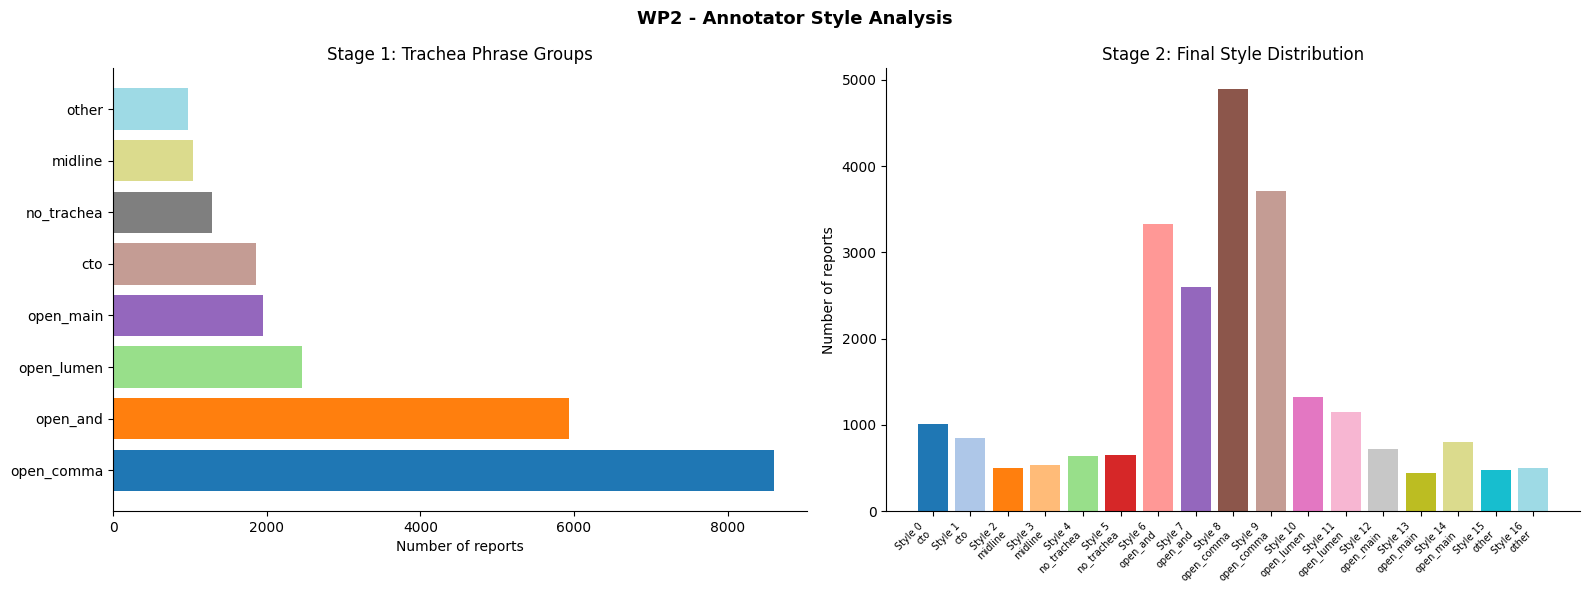

Saved: figures/style_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WP2 - Annotator Style Analysis', fontsize=13, fontweight='bold')

# plot 1: trachea phrase distribution (stage 1)
ax = axes[0]
phrase_counts = pd.Series(trachea_phrases).value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(phrase_counts)))
ax.barh(phrase_counts.index, phrase_counts.values, color=colors)
ax.set_title('Stage 1: Trachea Phrase Groups')
ax.set_xlabel('Number of reports')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plot 2: final style distribution (stage 2)
ax = axes[1]
style_counts = df['style_id'].value_counts().sort_index()
style_labels = [f"Style {i}\n{style_registry[i].split(' | ')[0]}"
                for i in style_counts.index]
colors2 = plt.cm.tab20(np.linspace(0, 1, len(style_counts)))
ax.bar(range(len(style_counts)), style_counts.values, color=colors2)
ax.set_xticks(range(len(style_counts)))
ax.set_xticklabels(style_labels, rotation=45, ha='right', fontsize=7)
ax.set_title('Stage 2: Final Style Distribution')
ax.set_ylabel('Number of reports')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'style_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/style_distribution.png")

Computing t-SNE projection ...


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 24128 samples in 0.002s...
[t-SNE] Computed neighbors for 24128 samples in 136.101s...
[t-SNE] Computed conditional probabilities for sample 1000 / 24128
[t-SNE] Computed conditional probabilities for sample 2000 / 24128
[t-SNE] Computed conditional probabilities for sample 3000 / 24128
[t-SNE] Computed conditional probabilities for sample 4000 / 24128
[t-SNE] Computed conditional probabilities for sample 5000 / 24128
[t-SNE] Computed conditional probabilities for sample 6000 / 24128
[t-SNE] Computed conditional probabilities for sample 7000 / 24128
[t-SNE] Computed conditional probabilities for sample 8000 / 24128
[t-SNE] Computed conditional probabilities for sample 9000 / 24128
[t-SNE] Computed conditional probabilities for sample 10000 / 24128
[t-SNE] Computed conditional probabilities for sample 11000 / 24128
[t-SNE] Computed conditional probabilities for sample 12000 / 24128
[t-SNE] Computed conditional probabilities for s

IndexError: boolean index did not match indexed array along axis 0; size of axis is 24128 but size of corresponding boolean axis is 24113

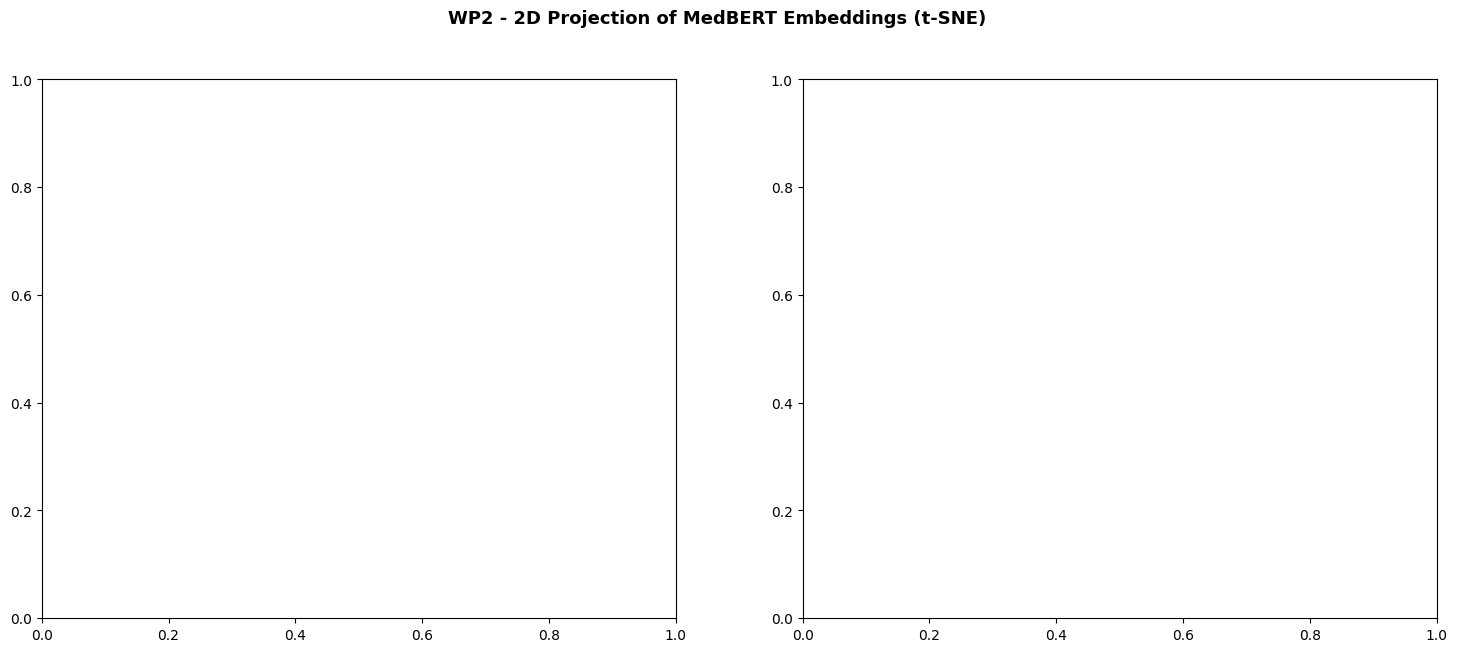

In [ ]:
from sklearn.manifold import TSNE

print("Computing t-SNE projection ...")

# first reduce to 50 dims with PCA for speed, then t-SNE
pca_pre = PCA(n_components=50, random_state=42)
X_pca_pre = pca_pre.fit_transform(embeddings)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    verbose=1
)
X_tsne = tsne.fit_transform(X_pca_pre)

print("t-SNE done!")


In [16]:
print(f"df shape:      {len(df)}")
print(f"embeddings shape: {embeddings.shape}")
print(f"X_tsne shape:  {X_tsne.shape}")

df shape:      24113
embeddings shape: (24128, 768)
X_tsne shape:  (24128, 2)


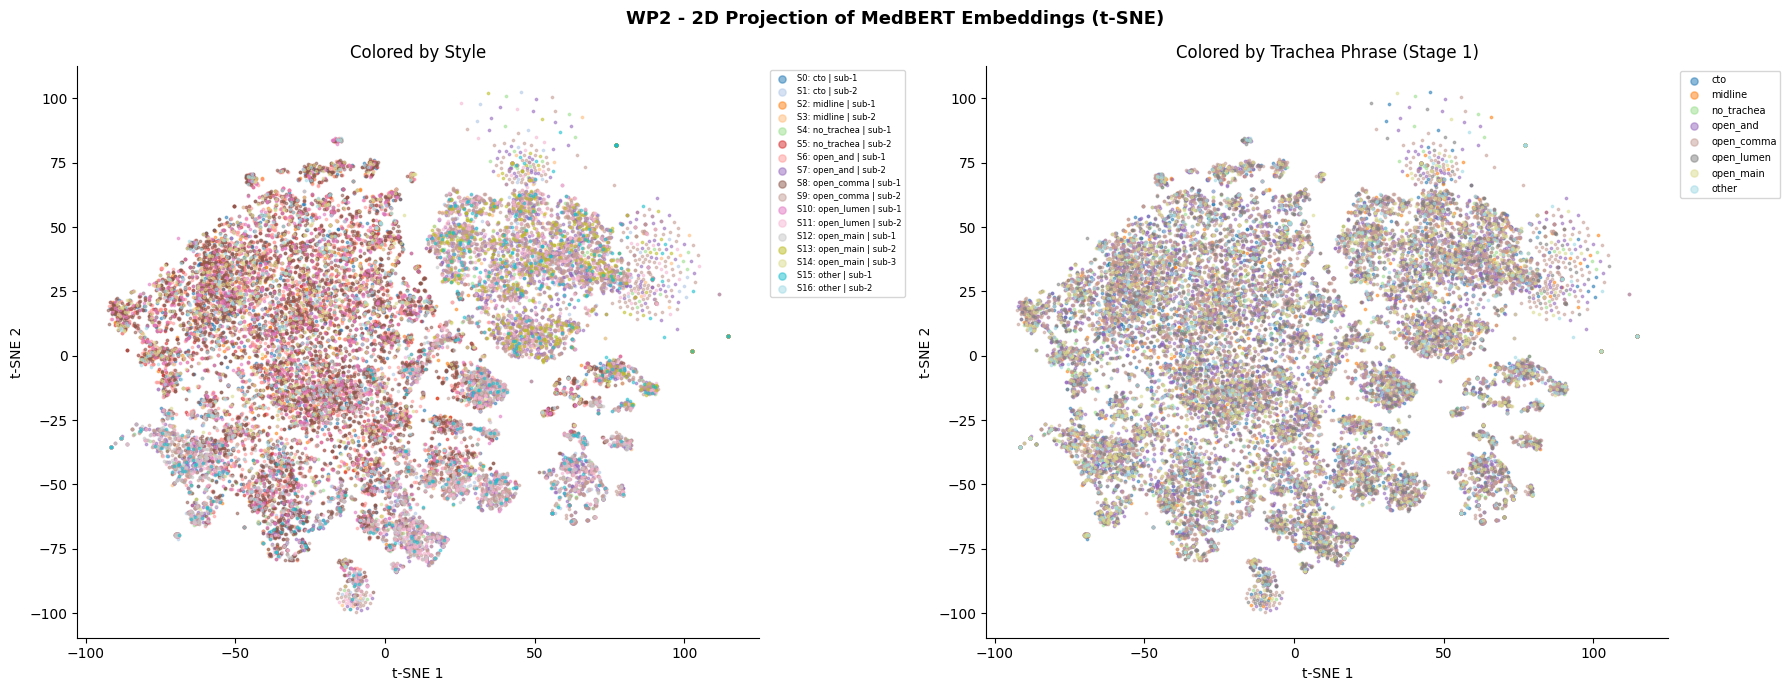

Saved: figures/tsne_projection.png


In [17]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('WP2 - 2D Projection of MedBERT Embeddings (t-SNE)',
             fontsize=13, fontweight='bold')
colors = plt.cm.tab20(np.linspace(0, 1, len(style_registry)))

# align t-SNE coordinates with current df index
df_indices = df.index.tolist()
X_tsne_aligned = X_tsne[df_indices]

# plot 1: colored by style_id
ax = axes[0]
for sid in sorted(style_registry.keys()):
    mask = df['style_id'].values == sid
    ax.scatter(
        X_tsne_aligned[mask, 0], X_tsne_aligned[mask, 1],
        c=[colors[sid % len(colors)]],
        label=f"S{sid}: {style_registry[sid][:20]}",
        s=3, alpha=0.5
    )
ax.set_title('Colored by Style')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=6, markerscale=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plot 2: colored by trachea phrase group
ax = axes[1]
unique_phrases  = sorted(set(trachea_phrases))
phrase_colors   = plt.cm.tab20(np.linspace(0, 1, len(unique_phrases)))
phrase_to_color = {p: phrase_colors[i] for i, p in enumerate(unique_phrases)}

for phrase in unique_phrases:
    mask = np.array([p == phrase for p in trachea_phrases])
    ax.scatter(
        X_tsne_aligned[mask, 0], X_tsne_aligned[mask, 1],
        c=[phrase_to_color[phrase]],
        label=phrase,
        s=3, alpha=0.5
    )
ax.set_title('Colored by Trachea Phrase (Stage 1)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=7, markerscale=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tsne_projection.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/tsne_projection.png")

**Note on interpretation**: the t-SNE projection shows a lot of overlap between styles. This can be expacted.
Annotator style differences are subtle compared variations regrading the clinical conteyt - even after masking clinical terms, 
MedBERT still captures semantic information that dominates the embedding space. 
The style separation is more present in the high-dimensional space used for GMM clustering than in  2D. 
The plot is therefore to be interpreted as an exploratory visualization rather than a validation of the clustering quality.

##  Temporal Analysis

To validate style identification, analyze when each style appears over time.
If a style is only active during a specific time period, this suggests it corresponds to a single annotator who worked 
during that period.

Findings:
The dataset spans from 2016 to 2022, which also covers the COVID-19 
pandemic period (2020+) - visible as a spike in overall report volume.


=== Temporal Distribution per Style ===

Style  | Description                    | n     | From     | To       | Active months
--------------------------------------------------------------------------------
S 0    | cto | sub-1                    |  1012 | 2016-01  | 2022-11  |  68/83 (82%)
S 1    | cto | sub-2                    |   845 | 2016-08  | 2022-11  |  66/83 (80%)
S 2    | midline | sub-1                |   502 | 2016-12  | 2022-11  |  64/83 (77%)
S 3    | midline | sub-2                |   534 | 2016-11  | 2022-11  |  59/83 (71%)
S 4    | no_trachea | sub-1             |   633 | 2017-03  | 2022-11  |  49/83 (59%)
S 5    | no_trachea | sub-2             |   655 | 2016-12  | 2022-11  |  57/83 (69%)
S 6    | open_and | sub-1               |  3334 | 2016-01  | 2022-11  |  78/83 (94%)
S 7    | open_and | sub-2               |  2598 | 2016-01  | 2022-11  |  73/83 (88%)
S 8    | open_comma | sub-1             |  4890 | 2016-01  | 2022-11  |  81/83 (98%)
S 9    | open_comma | sub-2

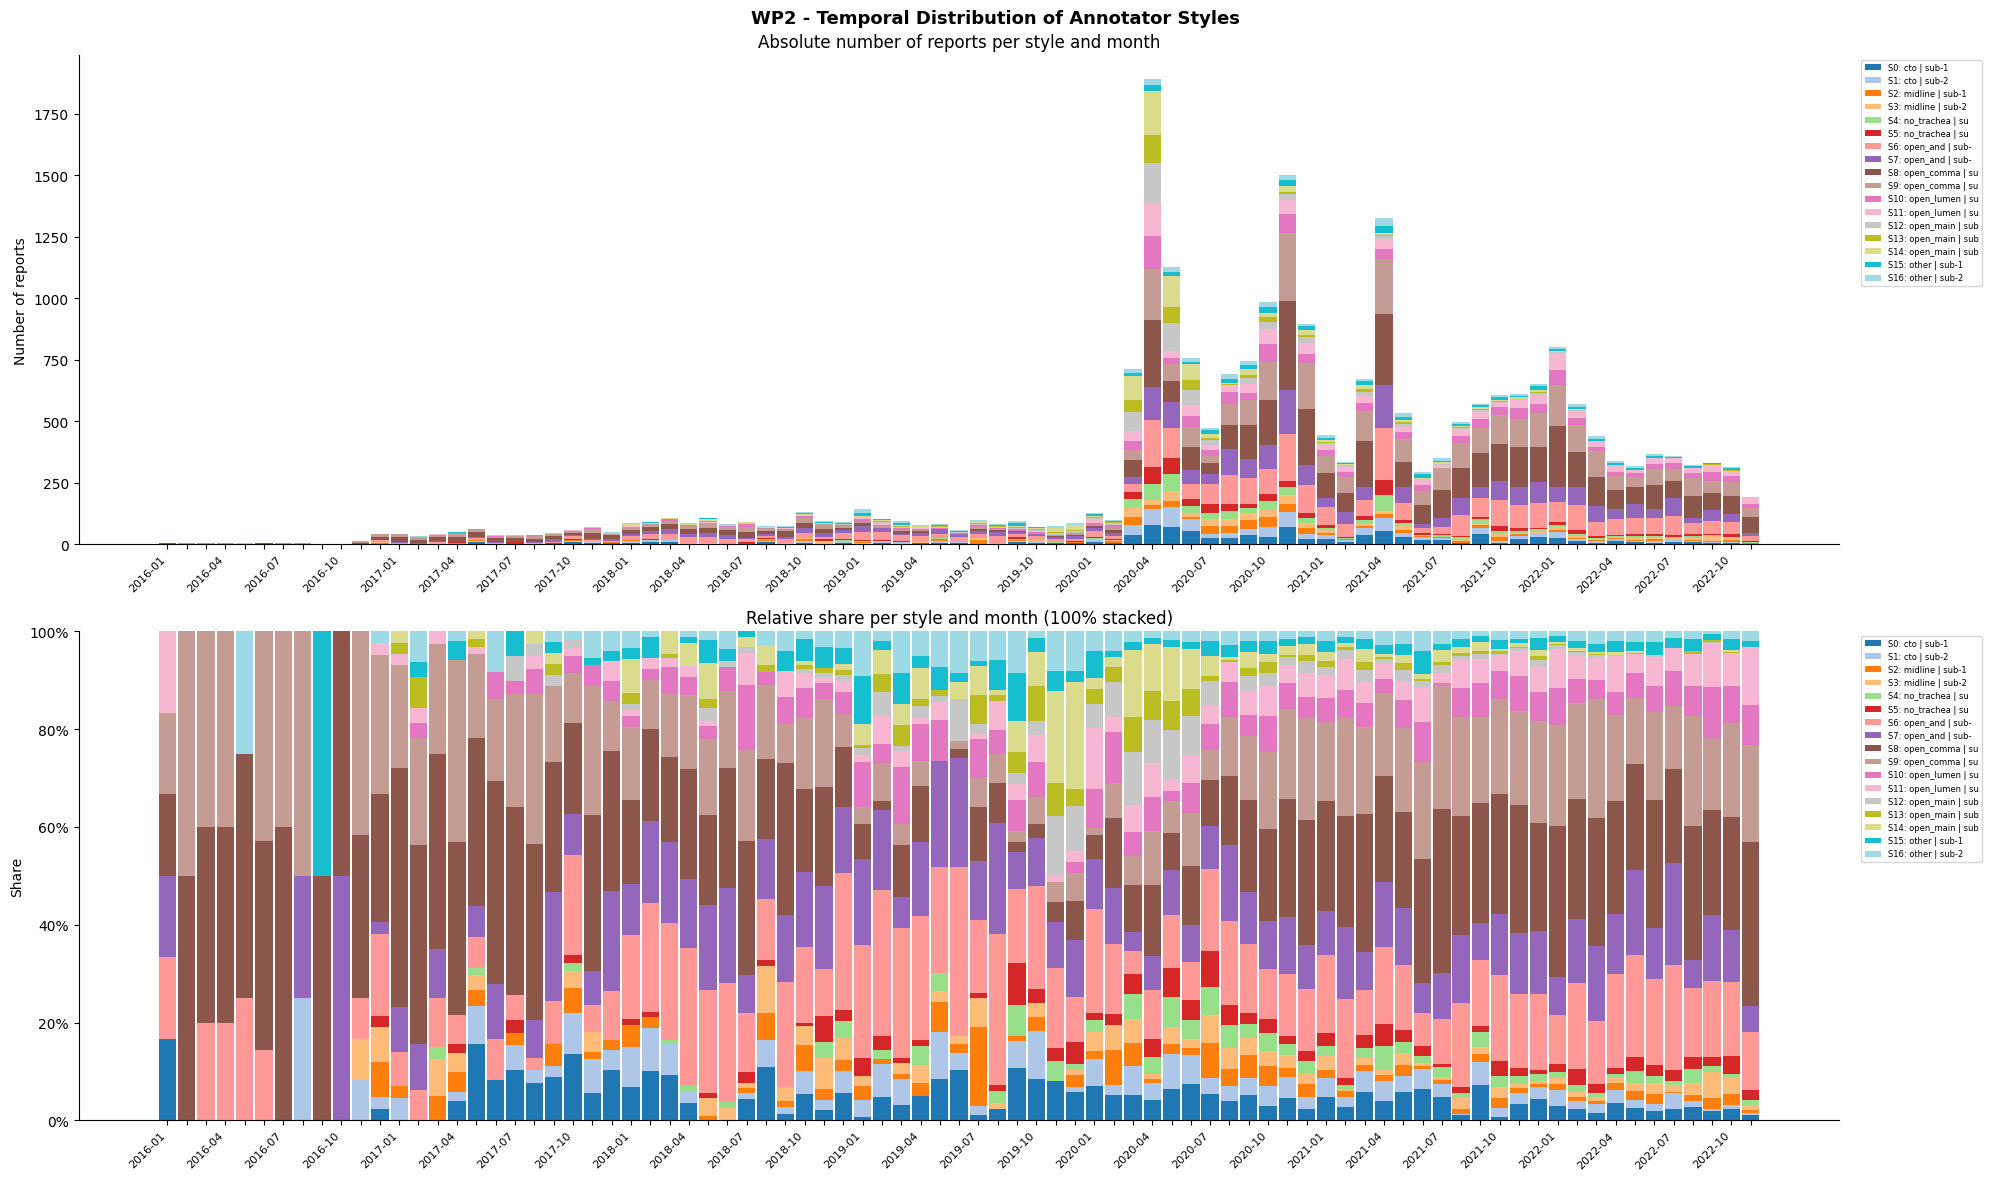

Saved: figures/temporal_distribution.png

Dataset time range: 2016-01 to 2022-11

Reports per year:
StudyDate
2016       98
2017      569
2018     1113
2019     1069
2020    10009
2021     6896
2022     4359


In [18]:
# convert StudyDate to datetime
df['StudyDate'] = pd.to_datetime(df['StudyDate'], format='%Y%m%d', errors='coerce')
df['year_month'] = df['StudyDate'].dt.to_period('M')

df_time      = df[df['StudyDate'].notna()].copy()
total_months = df_time['year_month'].nunique()

print("=== Temporal Distribution per Style ===\n")
print(f"{'Style':6s} | {'Description':30s} | {'n':5s} | "
      f"{'From':8s} | {'To':8s} | {'Active months'}")
print("-" * 80)

for sid in sorted(style_registry.keys()):
    subset = df_time[df_time['style_id'] == sid]
    if len(subset) == 0:
        continue
    date_min      = subset['StudyDate'].min().strftime('%Y-%m')
    date_max      = subset['StudyDate'].max().strftime('%Y-%m')
    months_active = subset['year_month'].nunique()
    pct_months    = months_active / total_months * 100
    desc          = style_registry[sid][:30]

    print(f"S{sid:2d}    | {desc:30s} | {len(subset):5d} | "
          f"{date_min:8s} | {date_max:8s} | "
          f"{months_active:3d}/{total_months} ({pct_months:.0f}%)")

# stacked bar chart
pivot      = df_time.groupby(['year_month', 'style_id']).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

x_labels = [str(p) if i % 3 == 0 else ''
             for i, p in enumerate(pivot.index)]
colors = plt.cm.tab20(np.linspace(0, 1, len(style_registry)))

fig, axes = plt.subplots(2, 1, figsize=(20, 12))
fig.suptitle('WP2 - Temporal Distribution of Annotator Styles',
             fontsize=13, fontweight='bold')

# plot 1: absolute counts
ax = axes[0]
bottom = np.zeros(len(pivot))
for sid in sorted(style_registry.keys()):
    if sid not in pivot.columns:
        continue
    values = pivot[sid].values
    ax.bar(range(len(pivot)), values, bottom=bottom,
           color=colors[sid % len(colors)],
           label=f"S{sid}: {style_registry[sid][:15]}",
           width=0.9)
    bottom += values

ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('Absolute number of reports per style and month')
ax.set_ylabel('Number of reports')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6, ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plot 2: relative share (100% stacked)
ax = axes[1]
bottom = np.zeros(len(pivot_norm))
for sid in sorted(style_registry.keys()):
    if sid not in pivot_norm.columns:
        continue
    values = pivot_norm[sid].values
    ax.bar(range(len(pivot_norm)), values, bottom=bottom,
           color=colors[sid % len(colors)],
           label=f"S{sid}: {style_registry[sid][:15]}",
           width=0.9)
    bottom += values

ax.set_xticks(range(len(pivot_norm)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('Relative share per style and month (100% stacked)')
ax.set_ylabel('Share')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6, ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'temporal_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/temporal_distribution.png")

# year distribution summary
print(f"\nDataset time range: "
      f"{df['StudyDate'].min().strftime('%Y-%m')} to "
      f"{df['StudyDate'].max().strftime('%Y-%m')}")
print(f"\nReports per year:")
print(df_time['StudyDate'].dt.year.value_counts().sort_index().to_string())

## Report Length Distribution per Style

Report length is a strong style indicator. 
some annotators write very detailed reports while others are more concise.
compare the distribution of findings length (in words) across styles.

=== Report Length per Style (words) ===

Style  | Description                    | Mean   | Median  | Std    | Min   | Max  
---------------------------------------------------------------------------
S 0    | cto | sub-1                    |  252.8 |   235.0 |   85.9 |    93 |   598
S 1    | cto | sub-2                    |  236.7 |   222.0 |   81.9 |    89 |   579
S 2    | midline | sub-1                |  232.4 |   217.0 |   65.7 |   107 |   527
S 3    | midline | sub-2                |  222.2 |   206.0 |   61.0 |   100 |   477
S 4    | no_trachea | sub-1             |  121.5 |   103.0 |   67.4 |     4 |   660
S 5    | no_trachea | sub-2             |  126.2 |   111.0 |   65.4 |     4 |   422
S 6    | open_and | sub-1               |  221.9 |   212.0 |   62.7 |    54 |   675
S 7    | open_and | sub-2               |  218.0 |   207.0 |   59.0 |    54 |   641
S 8    | open_comma | sub-1             |  182.9 |   169.0 |   56.5 |    84 |   545
S 9    | open_comma | sub-2             |  

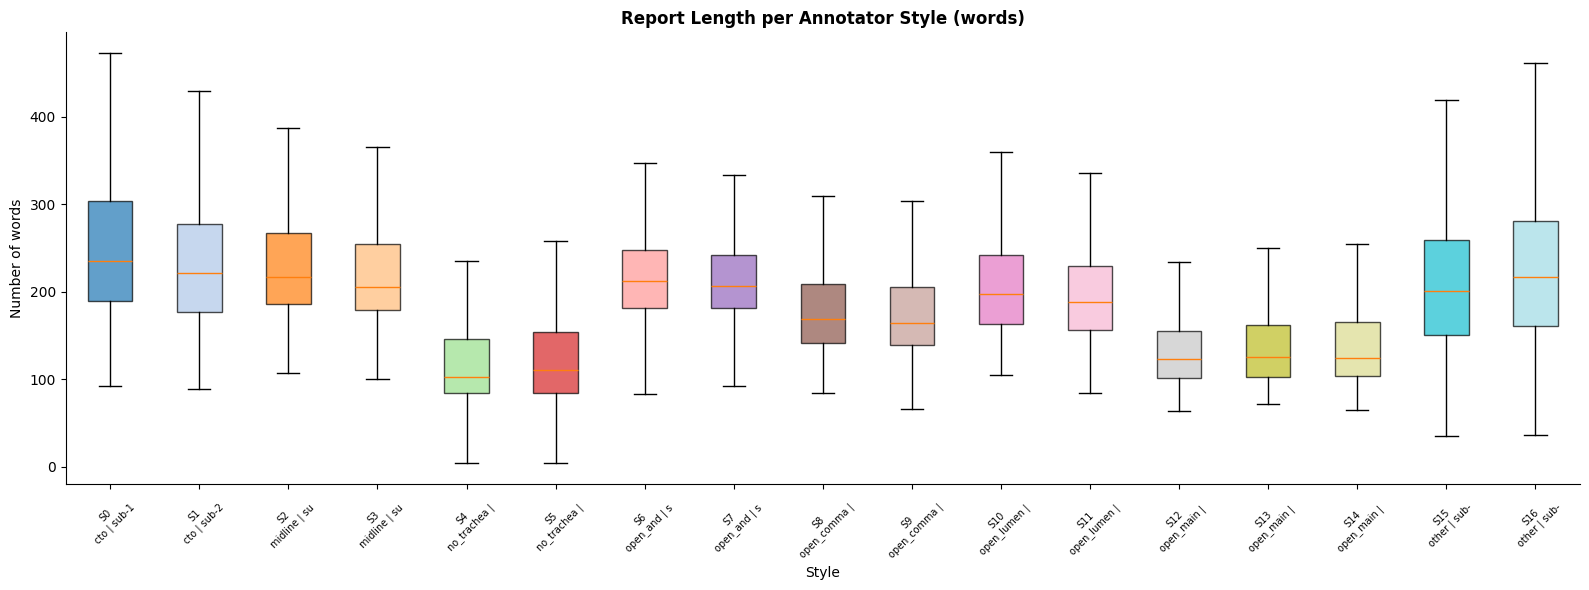

Saved: figures/report_length.png


In [19]:
df['findings_words'] = df['Findings_EN'].fillna('').apply(lambda x: len(x.split()))

length_stats = df.groupby('style_id')['findings_words'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(1)

print("=== Report Length per Style (words) ===\n")
print(f"{'Style':6s} | {'Description':30s} | {'Mean':6s} | "
      f"{'Median':7s} | {'Std':6s} | {'Min':5s} | {'Max':5s}")
print("-" * 75)

for sid, row in length_stats.iterrows():
    desc = style_registry[sid][:30]
    print(f"S{sid:2d}    | {desc:30s} | {row['mean']:6.1f} | "
          f"{row['median']:7.1f} | {row['std']:6.1f} | "
          f"{row['min']:5.0f} | {row['max']:5.0f}")

# boxplot
fig, ax = plt.subplots(figsize=(16, 6))

data_per_style = [
    df[df['style_id'] == sid]['findings_words'].values
    for sid in sorted(style_registry.keys())
]
tick_labels = [f"S{sid}\n{style_registry[sid][:12]}"
               for sid in sorted(style_registry.keys())]

bp = ax.boxplot(data_per_style, tick_labels=tick_labels,
                patch_artist=True, showfliers=False)

colors = plt.cm.tab20(np.linspace(0, 1, len(style_registry)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Report Length per Annotator Style (words)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Style')
ax.set_ylabel('Number of words')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'report_length.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/report_length.png")

## Lexical Diversity per Style

Lexical diversity measures how varied the vocabulary of each style is. 
compute three metrics:

- **TTR (Type-Token Ratio)**: unique words / total words
- **MATTR (Moving Average TTR)**: TTR computed over a sliding window of 
  50 words, then average
- **Hapax Ratio**: proportion of words that appear only once.

Computing lexical diversity metrics...

=== Lexical Diversity per Style ===

Style  | Description                    | TTR    | MATTR  | Hapax 
-----------------------------------------------------------------
S 0    | cto | sub-1                    |  0.515 |  0.738 |  0.688
S 1    | cto | sub-2                    |  0.525 |  0.739 |  0.694
S 2    | midline | sub-1                |  0.559 |  0.774 |  0.724
S 3    | midline | sub-2                |  0.567 |  0.776 |  0.731
S 4    | no_trachea | sub-1             |  0.626 |  0.753 |  0.735
S 5    | no_trachea | sub-2             |  0.621 |  0.750 |  0.733
S 6    | open_and | sub-1               |  0.526 |  0.754 |  0.675
S 7    | open_and | sub-2               |  0.526 |  0.754 |  0.674
S 8    | open_comma | sub-1             |  0.585 |  0.765 |  0.718
S 9    | open_comma | sub-2             |  0.587 |  0.766 |  0.718
S10    | open_lumen | sub-1             |  0.524 |  0.736 |  0.656
S11    | open_lumen | sub-2             |  0.529 |  0

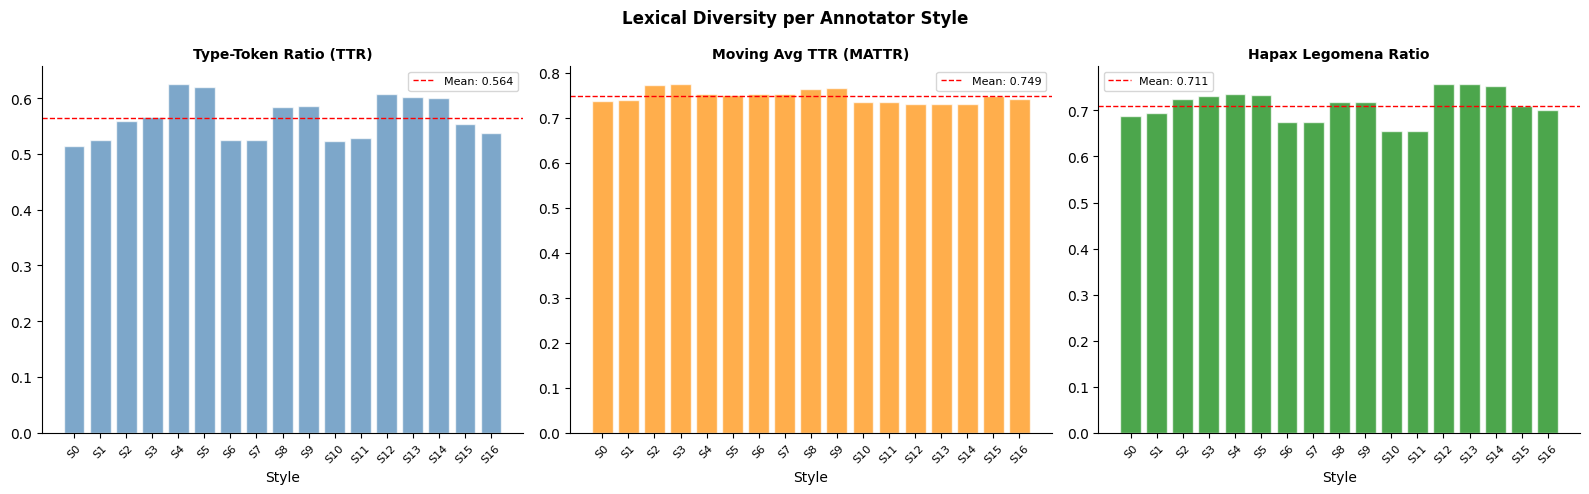

Saved: figures/lexical_diversity.png


In [20]:
def type_token_ratio(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

def moving_avg_ttr(text, window=50):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(words) < window:
        return type_token_ratio(text)
    ttrs = []
    for i in range(len(words) - window + 1):
        window_words = words[i:i+window]
        ttrs.append(len(set(window_words)) / window)
    return np.mean(ttrs)

def hapax_ratio(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(words) == 0:
        return 0
    counts = Counter(words)
    hapax = sum(1 for w, c in counts.items() if c == 1)
    return hapax / len(counts)

print("Computing lexical diversity metrics...")
df['ttr']   = df['Findings_EN'].fillna('').apply(type_token_ratio)
df['mattr'] = df['Findings_EN'].fillna('').apply(moving_avg_ttr)
df['hapax'] = df['Findings_EN'].fillna('').apply(hapax_ratio)

print("\n=== Lexical Diversity per Style ===\n")
print(f"{'Style':6s} | {'Description':30s} | {'TTR':6s} | "
      f"{'MATTR':6s} | {'Hapax':6s}")
print("-" * 65)

lex_stats = df.groupby('style_id')[['ttr', 'mattr', 'hapax']].mean().round(3)

for sid, row in lex_stats.iterrows():
    desc = style_registry[sid][:30]
    print(f"S{sid:2d}    | {desc:30s} | {row['ttr']:6.3f} | "
          f"{row['mattr']:6.3f} | {row['hapax']:6.3f}")

# visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Lexical Diversity per Annotator Style',
             fontsize=12, fontweight='bold')

metrics = [
    ('ttr',   'Type-Token Ratio (TTR)',  'steelblue'),
    ('mattr', 'Moving Avg TTR (MATTR)', 'darkorange'),
    ('hapax', 'Hapax Legomena Ratio',   'green'),
]

for ax, (metric, title, color) in zip(axes, metrics):
    values = [lex_stats.loc[sid, metric]
              for sid in sorted(style_registry.keys())
              if sid in lex_stats.index]
    labels = [f"S{sid}" for sid in sorted(style_registry.keys())
              if sid in lex_stats.index]

    ax.bar(labels, values, color=color, alpha=0.7, edgecolor='white')
    ax.axhline(np.mean(values), color='red', linestyle='--',
               linewidth=1, label=f'Mean: {np.mean(values):.3f}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Style')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'lexical_diversity.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/lexical_diversity.png")

## Most Frequent Terms per Style

Looking at the most frequent terms gives a understanding of what characterizes each style.
Remove common stopwords; only consider words of at least 4 characters to focus on meaningful 
medical and stylistic terms.

=== Most Frequent Terms per Style ===

Style  0 | cto | sub-1
  observed(6251), normal(4506), detected(3708), calibration(2886), lung(2735), lobe(2191), right(2095), level(1987), upper(1935), lymph(1833)



Style  1 | cto | sub-2
  observed(4893), normal(3672), detected(3135), calibration(2297), lung(2187), lobe(1707), upper(1544), right(1529), level(1497), area(1479)

Style  2 | midline | sub-1
  observed(3354), detected(2205), normal(1763), lung(1588), thickening(1145), lesion(1004), structures(892), lobe(889), main(882), lungs(869)

Style  3 | midline | sub-2
  observed(3380), detected(2345), normal(1897), lung(1670), thickening(1187), lesion(1100), main(953), structures(920), lobe(874), area(871)

Style  4 | no_trachea | sub-1
  observed(2007), detected(1761), lung(1375), parenchyma(951), structures(877), size(800), upper(761), lymph(737), pathological(730), appearance(720)

Style  5 | no_trachea | sub-2
  observed(2112), detected(1666), lung(1447), parenchyma(931), structures(850), upper(809), effusion(752), size(736), lymph(716), pathological(687)

Style  6 | open_and | sub-1
  observed(16886), detected(15993), normal(9519), main(8233), structures(7655), sections(7652), lungs(6999),

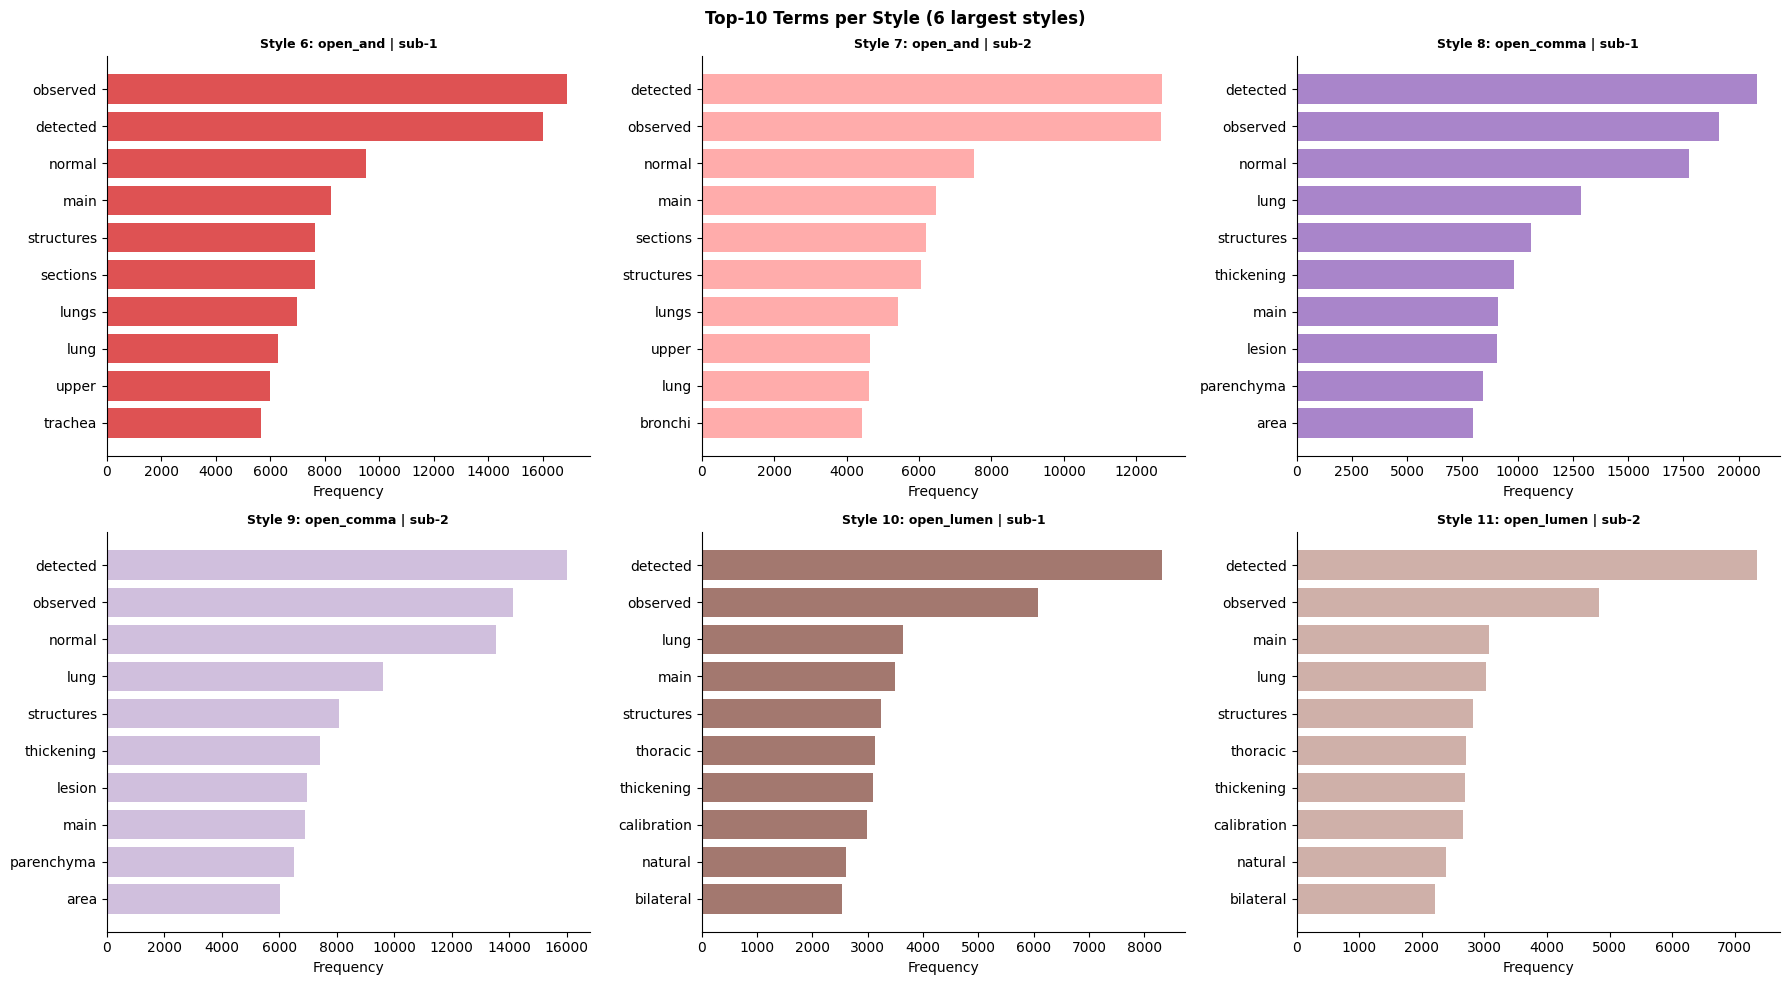

Saved: figures/frequent_terms.png


In [21]:
STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'of', 'in', 'is', 'are', 'was',
    'were', 'be', 'been', 'being', 'to', 'for', 'with', 'at', 'by',
    'from', 'as', 'on', 'not', 'no', 'it', 'its', 'this', 'that',
    'both', 'also', 'which', 'have', 'has', 'had', 'do', 'does',
    'did', 'will', 'would', 'could', 'should', 'may', 'might',
    'there', 'their', 'they', 'them', 'these', 'those', 'than',
    'into', 'within', 'without', 'around', 'between', 'through',
    'can', 'cannot', 'all', 'any', 'each', 'more', 'most',
    'other', 'such', 'only', 'same', 'so', 'too', 'very',
    'just', 'but', 'if', 'then', 'because', 'while', 'after',
    'before', 'above', 'below', 'out', 'off', 'over', 'under',
    'again', 'once', 'here', 'where', 'what', 'when', 'who'
}

def get_top_terms(texts, n=10):
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
        words = [w for w in words if w not in STOPWORDS]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

print("=== Most Frequent Terms per Style ===\n")
all_top_terms = {}

for sid in sorted(style_registry.keys()):
    style_texts = df[df['style_id'] == sid]['Findings_EN'].fillna('').tolist()
    top_terms   = get_top_terms(style_texts, n=10)
    all_top_terms[sid] = top_terms
    desc        = style_registry[sid]
    terms_str   = ', '.join([f"{w}({c})" for w, c in top_terms])
    print(f"Style {sid:2d} | {desc}")
    print(f"  {terms_str}\n")

# visualize top 6 largest styles
top_styles = df['style_id'].value_counts().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top-10 Terms per Style (6 largest styles)',
             fontsize=12, fontweight='bold')

for ax, sid in zip(axes.flat, sorted(top_styles)):
    terms  = all_top_terms[sid][:10]
    words  = [t[0] for t in terms]
    counts = [t[1] for t in terms]

    ax.barh(words[::-1], counts[::-1],
            color=plt.cm.tab20(sid / 20), alpha=0.8)
    ax.set_title(f"Style {sid}: {style_registry[sid][:25]}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'frequent_terms.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/frequent_terms.png")

### Comparison with CT-RATE Paper Findings

The CT-RATE paper (Hamamci et al., 2024) reports in Figure 2c that reports 
vary considerably in length and are authored by numerous radiologists with 
different writing styles. 
Summarize findings and compare them 
to what the paper describes.

In [22]:
print("CT-RATE Paper reports (Figure 2c):")
print("  - Reports vary considerably in length")
print("  - Authored by numerous radiologists")
print("  - Different writing styles due to translation from Turkish\n")


print("OUR FINDINGS:")

print(f"\n1. NUMBER OF IDENTIFIED ANNOTATOR STYLES:")
print(f"   {len(style_registry)} distinct style profiles")
print(f"   of which {sum(1 for v in style_registry.values() if 'sub' in v)} "
      f"were refined by MedBERT sub-clustering")

print(f"\n2. TRACHEA OPENING PHRASES:")
phrase_counts = Counter(trachea_phrases)
for phrase, count in phrase_counts.most_common():
    pct = count / len(df) * 100
    print(f"   {phrase:25s}: {count:5d} ({pct:5.1f}%)")

print(f"\n3. REPORT LENGTHS:")
print(f"   Overall mean:   {df['findings_words'].mean():.1f} words")
print(f"   Overall std:    {df['findings_words'].std():.1f} words")
print(f"   Min:            {df['findings_words'].min():.0f} words")
print(f"   Max:            {df['findings_words'].max():.0f} words")
print(f"\n   Mean per style:")
for sid in sorted(style_registry.keys()):
    subset = df[df['style_id'] == sid]
    print(f"   Style {sid:2d}: {subset['findings_words'].mean():6.1f} words"
          f" | {style_registry[sid][:30]}")

print(f"\n4. LEXICAL DIVERSITY:")
print(f"   Overall mean MATTR: {df['mattr'].mean():.3f}")
print(f"   Highest diversity:  "
      f"Style {lex_stats['mattr'].idxmax()} "
      f"({lex_stats['mattr'].max():.3f})")
print(f"   Lowest diversity:   "
      f"Style {lex_stats['mattr'].idxmin()} "
      f"({lex_stats['mattr'].min():.3f})")

print(f"\n5. TEMPORAL DISTRIBUTION:")
print(f"   Dataset range: "
      f"{df['StudyDate'].min().strftime('%Y-%m')} to "
      f"{df['StudyDate'].max().strftime('%Y-%m')}")
print(f"   Styles active throughout (>80% of months): "
      f"{sum(1 for sid in style_registry if df_time[df_time['style_id']==sid]['year_month'].nunique() / total_months > 0.8)}")
print(f"   Styles only in sub-period (<50% of months): "
      f"{sum(1 for sid in style_registry if df_time[df_time['style_id']==sid]['year_month'].nunique() / total_months < 0.5)}")

print(f"\n6. CONFIRMATION OF PAPER FINDINGS:")
print(f"   ✓ Substantial variation in report length confirmed")
print(f"     (std = {df['findings_words'].std():.1f} words)")
print(f"   ✓ Multiple distinct writing styles identified "
      f"({len(style_registry)} styles)")
print(f"   ✓ Stylistic variation evidenced by consistent phrase patterns")
print(f"   ✓ Temporal analysis reveals annotator turnover over time")

CT-RATE Paper reports (Figure 2c):
  - Reports vary considerably in length
  - Authored by numerous radiologists
  - Different writing styles due to translation from Turkish

OUR FINDINGS:

1. NUMBER OF IDENTIFIED ANNOTATOR STYLES:
   17 distinct style profiles
   of which 17 were refined by MedBERT sub-clustering

2. TRACHEA OPENING PHRASES:
   open_comma               :  8601 ( 35.7%)
   open_and                 :  5932 ( 24.6%)
   open_lumen               :  2464 ( 10.2%)
   open_main                :  1956 (  8.1%)
   cto                      :  1857 (  7.7%)
   no_trachea               :  1288 (  5.3%)
   midline                  :  1036 (  4.3%)
   other                    :   979 (  4.1%)

3. REPORT LENGTHS:
   Overall mean:   195.6 words
   Overall std:    71.4 words
   Min:            4 words
   Max:            1035 words

   Mean per style:
   Style  0:  252.8 words | cto | sub-1
   Style  1:  236.7 words | cto | sub-2
   Style  2:  232.4 words | midline | sub-1
   Style  3: 

## Save Results

Save the final DataFrame with style assignments, a readable 
style profile summary, and the embeddings for potential reuse.

All figures are saved to the `figures/` folder during the analysis.

In [23]:
# save final DataFrame with style assignments
df.to_csv('df_wp2_final.csv', index=False)

# save human-readable style profiles
with open('style_profiles.txt', 'w') as f_out:
    f_out.write("WP2 - Annotator Style Profiles\n")
    f_out.write("=" * 60 + "\n\n")
    f_out.write(f"Method: Trachea phrase detection (Stage 1) + "
                f"MedBERT sub-clustering (Stage 2)\n")
    f_out.write(f"Total reports: {len(df)}\n")
    f_out.write(f"Total styles:  {len(style_registry)}\n\n")

    for sid, desc in sorted(style_registry.items()):
        n       = (df['style_id'] == sid).sum()
        pct     = n / len(df) * 100
        mean_w  = df[df['style_id'] == sid]['findings_words'].mean()
        mattr_v = lex_stats.loc[sid, 'mattr'] if sid in lex_stats.index else 0
        top5    = ', '.join([w for w, c in all_top_terms.get(sid, [])[:5]])

        f_out.write(f"Style {sid:2d} (n={n:5d}, {pct:5.1f}%)\n")
        f_out.write(f"  Description:  {desc}\n")
        f_out.write(f"  Mean length:  {mean_w:.1f} words\n")
        f_out.write(f"  MATTR:        {mattr_v:.3f}\n")
        f_out.write(f"  Top-5 terms:  {top5}\n\n")

# embeddings are already saved as embeddings_wp2_v4.npy

print("Saved:")
print("  - df_wp2_final.csv")
print("  - style_profiles.txt")
print(f"  - figures/ ({len(os.listdir(FIGURES_DIR))} plots)")

Saved:
  - df_wp2_final.csv
  - style_profiles.txt
  - figures/ (6 plots)
